In [23]:
import pandas as pd
import ast
import os
import glob

In [24]:
def load_answer(institution, year):
    ANSWER_PATH = "../data/answer/rank.xlsx"
    latest_answer_df = pd.read_excel(ANSWER_PATH)
    if(institution[2:4] == "金控"):
        institution = institution[0:2] + "金"
    # print(latest_answer_df)
    # print(institution)
    year = int(year)
    answer_for_institution = latest_answer_df[latest_answer_df['Financial_Institutions'] == institution]
    # print(f"Unique values in latest_answer_df['Year']: {latest_answer_df['Year'].unique()}")
    # print(f"Type of 'Year' column: {latest_answer_df['Year'].dtype}")
    # print(f"Value of year: {year}, type: {type(year)}")
    answer_for_institution = answer_for_institution[answer_for_institution['Year'] == year]

    # print(answer_for_institution)
    if not answer_for_institution.empty:
        columns_to_print = answer_for_institution.loc[:, "Q1":"Q82"].iloc[0].to_dict()
    else:
        raise ValueError(f"No matching answers found for institution {institution} in year {year}")

    # print(answer_for_institution.loc[:, "Q1":"Q82"])
    return columns_to_print

In [ ]:
input_dir  = "../data/tcfd_report_pdf_chunks_matching_result_第四層"
output_dir = "analysis_results"  
os.makedirs(output_dir, exist_ok=True)
output_csv = os.path.join(output_dir, "retrieval_only_results.csv")

rows = []

for path in glob.glob(os.path.join(input_dir, "*_matched_chunks.csv")):
    filename = os.path.basename(path)
    inst, year, *_ = filename.split("_")
    year = int(year)
    
    df = pd.read_csv(path)
    report_list = [
        {
            'Matched_Categories': ast.literal_eval(row['Matched_Categories'])
        }
        for _, row in df.iterrows()
    ]
    matched_ids = set()
    for entry in report_list:
        for cat in entry['Matched_Categories']:
            clean = cat.replace('#', '').split('_')[-1]
            matched_ids.add(clean)
    
    answer_dict = load_answer(inst, year)
    
    row = {
        "Institution": inst,
        "Year": year
    }
    for q, val in answer_dict.items():
        if isinstance(val, float) and pd.isna(val):
            row[q] = pd.NA
            continue
        
        qid = q[1:]  # 將 "Q12" -> "12"
        # 比對：若標準答案是 1 且出現在 matched_ids，或是標準答案是 0 且不在 matched_ids，就算答對
        correct = (
            (val == 1.0 and qid in matched_ids)
            or
            (val == 0.0 and qid not in matched_ids)
        )
        row[q] = 1 if correct else 0
    
    rows.append(row)

result_df = pd.DataFrame(rows)
result_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"Finished! 輸出檔案：{output_csv}")


Finished! 輸出檔案：analysis_results\retrieval_only_results.csv


In [26]:
retrieval_only_df = pd.read_csv('analysis_results/retrieval_only_results.csv')
retrieval_only_df

,Institution,Year,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,QMT5,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82
0,上海商銀,2022,1,1,1,0,1,1,1,1,...,1,0,1,1,1,0,0,1,0,1
1,中信金控,2021,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,1,1,1
2,中信金控,2022,1,1,1,0,1,1,1,1,...,1,1,0,0,1,0,0,0,0,0
3,中信銀行,2022,0,0,1,0,1,1,1,0,...,1,1,1,0,1,0,0,0,0,0
4,中輸銀行,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
5,元大金控,2021,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
6,元大金控,2022,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,1
7,元大銀行,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,兆豐金控,2021,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,1,1,1,1
9,兆豐金控,2022,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0


In [ ]:
q_cols = [c for c in retrieval_only_df.columns if c.startswith('Q')]

total_answers = retrieval_only_df[q_cols].notna().sum().sum()
ones_count    = (retrieval_only_df[q_cols] == 1).sum().sum()
accuracy = ones_count / total_answers

print(f"Overall accuracy (全部 1 的佔比)：{accuracy:.4%}")

Overall accuracy (全部 1 的佔比)：71.2394%


In [45]:
llm_only_df = pd.read_csv('analysis_results/llm_only_results.csv')
llm_only_df.head()

,Report,Chunk ID,Label,Question,Answer
0,兆豐金控_2021.pdf,0,G-1-1_1,公司是否描述向董事會和/或董事會下設委員會，定期報告氣候相關風險與機會之流程？,Yes
1,兆豐金控_2021.pdf,0,G-1-1_2,公司是否描述向董事會和/或董事會下設委員會，報告氣候相關風險與機會之頻率？,Yes
2,兆豐金控_2021.pdf,0,G-1-2_3,公司是否描述董事會和/或董事會下設委員會，在監督和指導策略、重要行動計畫、風險管理政策、年度...,Yes
3,兆豐金控_2021.pdf,0,G-1-2_4,公司是否描述董事會和/或董事會下設委員會，在監督重要資本支出、企業收購和撤資時，考量氣候相關...,Yes
4,兆豐金控_2021.pdf,0,G-1-3_5,公司是否描述董事會或其所屬和/或指派之委員會如何監督風險與機會目標之實現？,Yes


In [ ]:
llm_only_df = pd.read_csv('analysis_results/llm_only_results.csv')

# Clean the Report column and extract Institution and Year
llm_only_df['Report'] = llm_only_df['Report'].str.replace('.pdf$', '', regex=True)
llm_only_df[['Institution', 'Year']] = llm_only_df['Report'].str.rsplit('_', n=1, expand=True)
llm_only_df['Year'] = llm_only_df['Year'].astype(int)

# Extract question ID from Label and add Q prefix
llm_only_df['QID'] = llm_only_df['Label'].str.rsplit('_', n=1).str[1]
llm_only_df['Q'] = 'Q' + llm_only_df['QID']

# Convert Answer to numeric Value
llm_only_df['Value'] = llm_only_df['Answer'].map(lambda x: 1 if str(x).strip().lower()=='yes' else 0)

# Pivot to wide format
pivot = (
    llm_only_df
    .pivot_table(
        index=['Institution','Year'],
        columns='Q',
        values='Value',
        aggfunc='first'
    )
    .reset_index()
)

all_q_original = [c for c in pivot.columns if c.startswith('Q')]
all_q_clean = [c.replace('#', '') for c in all_q_original]

column_mapping = dict(zip(all_q_original, all_q_clean))
pivot = pivot.rename(columns=column_mapping)
all_q = [c for c in pivot.columns if c.startswith('Q')]

numeric_q = []
textual_q = []
for q in all_q:
    suffix = q[1:]
    if suffix.isdigit():
        numeric_q.append(q)
    else:
        print(f"Non-numeric Q column: {q}")
        textual_q.append(q)


numeric_q = sorted(numeric_q, key=lambda s: int(s[1:]))
textual_q = sorted(textual_q)
ordered_q = numeric_q + textual_q
pivot[ordered_q] = pivot[ordered_q].fillna(0).astype(int)
final = pivot[['Institution','Year'] + ordered_q]
final.to_csv('analysis_results/llm_only_df_results_modified.csv', index=False, encoding='utf-8-sig')

print("Output saved to: analysis_results/llm_only_df_results_modified.csv")
print("Columns in final output (# symbols removed):", final.columns.tolist())
print(f"Total columns: {len(final.columns)}")
print(f"Total numeric Q columns: {len(numeric_q)}")
print(f"Total text-based Q columns: {len(textual_q)}")

Non-numeric Q column: QMT1
Non-numeric Q column: QMT2
Non-numeric Q column: QMT3
Non-numeric Q column: QMT4
Non-numeric Q column: QMT5
Non-numeric Q column: QR1
Non-numeric Q column: QR2
Non-numeric Q column: QS1
Non-numeric Q column: QS2
Done! Output saved to: analysis_results/llm_only_df_results_modified.csv
Columns in final output (# symbols removed): ['Institution', 'Year', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q38', 'Q39', 'Q40', 'Q41', 'Q42', 'Q43', 'Q44', 'Q45', 'Q46', 'Q47', 'Q48', 'Q49', 'Q50', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58', 'Q59', 'Q60', 'Q61', 'Q62', 'Q63', 'Q64', 'Q65', 'Q66', 'Q67', 'Q68', 'Q69', 'Q70', 'Q71', 'Q72', 'Q73', 'Q74', 'Q75', 'Q76', 'Q77', 'Q78', 'Q79', 'Q80', 'Q81', 'Q82', 'QMT1', 'QMT2', 'QMT3', 'QMT4', 'QMT5', 'QR1', 'QR2', 

In [52]:
llm_only_df = pd.read_csv('analysis_results/llm_only_df_results_modified.csv')
rank_df = pd.read_excel('../data/answer/rank.xlsx')

In [53]:
llm_only_df

,Institution,Year,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q82,QMT1,QMT2,QMT3,QMT4,QMT5,QR1,QR2,QS1,QS2
0,兆豐金控,2021,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,1,1
1,兆豐金控,2022,1,1,1,1,1,1,1,1,...,0,1,0,0,1,1,1,1,0,1
2,兆豐銀行,2022,1,1,1,1,1,1,1,1,...,0,1,1,0,1,1,1,0,1,1
3,台中銀行,2022,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,1,1
4,台新金控,2022,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
5,台新銀行,2022,1,1,1,1,1,1,1,1,...,0,1,0,1,1,0,1,1,1,1
6,台灣企銀,2021,1,1,1,1,1,1,1,1,...,0,1,0,0,1,1,1,1,1,1
7,台灣企銀,2022,1,1,1,1,1,1,1,1,...,0,1,1,0,0,1,1,1,1,1
8,合庫金控,2022,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,1,1
9,安泰銀行,2022,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [54]:
rank_df

,Symbol,Financial_Institutions,Format,Year,1,2,3,4,5,6,...,R_2,R_3,MT_1,MT_2,MT_3,G,S,R,MT,Disclosure
0,2881,富邦金,1.0,2022,Y,Y,Y,Y,Y,Y,...,0.833333,1.0,0.833333,1.000000,1.0000,0.937500,0.972222,0.911111,0.944444,0.941319
1,5880,合庫金,1.0,2022,Y,Y,Y,Y,Y,Y,...,1.000000,1.0,0.541667,1.000000,1.0000,1.000000,0.913889,1.000000,0.847222,0.940278
2,5849,永豐銀行,1.0,2022,Y,Y,Y,N,Y,Y,...,1.000000,1.0,0.645833,0.888889,1.0000,0.854167,0.975000,0.866667,0.844907,0.885185
3,2891,中信金,1.0,2022,Y,Y,Y,N,Y,Y,...,1.000000,0.5,0.645833,0.888889,0.7500,0.916667,0.972222,0.833333,0.761574,0.870949
4,2884,玉山金,1.0,2022,Y,Y,Y,N,Y,Y,...,0.833333,1.0,0.625000,1.000000,0.7500,0.916667,0.813889,0.944444,0.791667,0.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2880,華南金,2.0,2022,Y,Y,N,N,N,N,...,0.000000,0.0,0.187500,0.666667,0.6250,0.166667,0.161111,0.133333,0.493056,0.238542
76,2889,國票金,2.0,2021,N,N,Y,N,Y,Y,...,0.000000,0.0,0.208333,0.000000,0.3125,0.416667,0.100000,0.000000,0.173611,0.172569
77,2893,新光銀行,2.0,2021,N,N,N,N,N,N,...,0.000000,0.0,0.166667,0.666667,0.0000,0.000000,0.155556,0.066667,0.277778,0.125000
78,6039,將來銀行,NaN,2022,Y,Y,Y,N,N,Y,...,0.000000,0.5,0.041667,0.000000,0.3125,0.687500,0.361111,0.300000,0.118056,0.366667


In [55]:
llm_df = llm_only_df.copy()
llm_df['Institution_mapped'] = llm_df['Institution'].str.replace('控$', '', regex=True)

# 2. Merge on mapped institution name & year
merged = pd.merge(
    llm_df,
    rank_df,
    left_on=['Institution_mapped', 'Year'],
    right_on=['Financial_Institutions', 'Year'],
    how='inner',
    suffixes=('_llm', '_rank')
)

# 3. Identify the 91 label columns (exclude Institution & Year)
label_cols = [col for col in llm_only_df.columns if col not in ['Institution', 'Year']]

# 4. Compute agreement: 1 if both match, else 0
agreement_df = merged[['Institution', 'Year']].copy()
for col in label_cols:
    agreement_df[col] = (merged[f'{col}_llm'] == merged[f'{col}_rank']).astype(int)
agreement_df

,Institution,Year,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q82,QMT1,QMT2,QMT3,QMT4,QMT5,QR1,QR2,QS1,QS2
0,兆豐金控,2021,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,1,1,0,0
1,兆豐金控,2022,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,1,1,1,1
2,兆豐銀行,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
3,台中銀行,2022,1,1,1,0,1,1,0,1,...,1,1,1,0,0,1,1,1,1,1
4,台新金控,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
5,台新銀行,2022,1,0,1,0,1,1,1,1,...,0,0,1,1,1,1,1,0,1,1
6,台灣企銀,2021,1,0,1,0,1,1,1,1,...,1,1,1,1,0,1,1,1,1,1
7,台灣企銀,2022,1,1,1,0,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
8,合庫金控,2022,1,1,1,1,1,1,1,1,...,0,1,0,0,0,1,1,1,1,1
9,安泰銀行,2022,0,0,0,1,0,0,0,0,...,0,0,1,1,1,0,0,0,0,1


In [ ]:
retrieval_only_df = pd.read_csv('analysis_results/retrieval_only_results.csv')

In [40]:
retrieval_only_df

,Institution,Year,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,QMT5,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82
0,上海商銀,2022,1,1,1,0,1,1,1,1,...,1,0,1,1,1,0,0,1,0,1
1,中信金控,2021,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,1,1,1
2,中信金控,2022,1,1,1,0,1,1,1,1,...,1,1,0,0,1,0,0,0,0,0
3,中信銀行,2022,0,0,1,0,1,1,1,0,...,1,1,1,0,1,0,0,0,0,0
4,中輸銀行,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
5,元大金控,2021,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
6,元大金控,2022,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,1
7,元大銀行,2022,1,1,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,兆豐金控,2021,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,1,1,1,1
9,兆豐金控,2022,1,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0


In [56]:
ret = retrieval_only_df.set_index(['Institution','Year'])
llm = agreement_df.set_index(['Institution','Year'])


common_idx = ret.index.intersection(llm.index)
ret = ret.loc[common_idx]
llm = llm.loc[common_idx]


q_cols = [c for c in ret.columns if c.startswith('Q')]


for q in q_cols:
    if q not in llm.columns:
        llm[q] = 0


llm = llm[q_cols]

matches = (ret[q_cols] == llm[q_cols])

total_matches = matches.values.sum()
total_labels  = matches.size
accuracy      = total_matches / total_labels

print(f"共有 {len(common_idx)} 個機構+年分要比對")
print(f"Q 欄位總數：{len(q_cols)}")
print(f"完全一致的次數：{total_matches} / {total_labels}")
print(f"一致率：{accuracy:.2%}")

共有 15 個機構+年分要比對
Q 欄位總數：91
完全一致的次數：924 / 1365
一致率：67.69%


In [58]:
import matplotlib.pyplot as plt

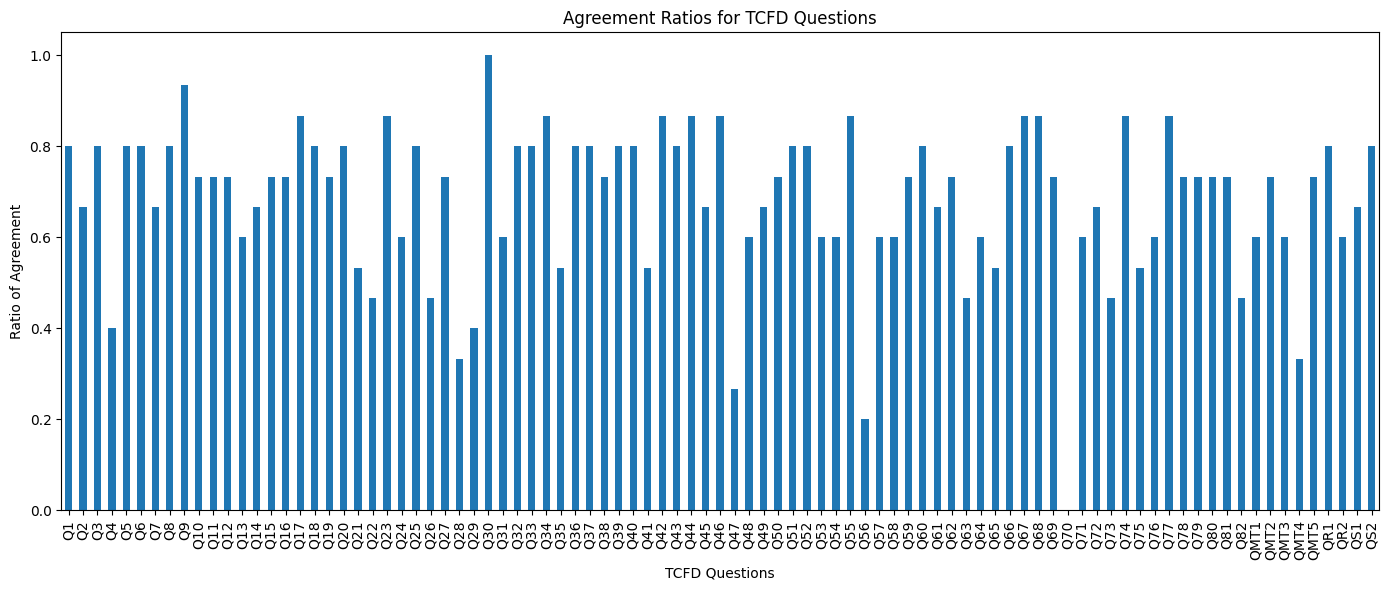

In [60]:
llm_df = llm_only_df.copy()
llm_df['Institution_mapped'] = llm_df['Institution'].str.replace('控$', '', regex=True)

# 2. 合併兩份資料
merged = pd.merge(
    llm_df,
    rank_df,
    left_on=['Institution_mapped', 'Year'],
    right_on=['Financial_Institutions', 'Year'],
    how='inner',
    suffixes=('_llm', '_rank')
)

# 3. 取得所有要比對的欄位（除了 Institution 與 Year）
label_cols = [col for col in llm_only_df.columns if col not in ['Institution', 'Year']]

# 4. 計算每一題的一致矩陣
agreement = pd.DataFrame({
    col: (merged[f'{col}_llm'] == merged[f'{col}_rank']).astype(int)
    for col in label_cols
})

# 5. 計算每題的一致比例
ratios = agreement.mean()

# 6. 畫出長條圖
plt.figure(figsize=(14, 6))
ratios.plot(kind='bar')
plt.xticks(rotation=90)
plt.xlabel('TCFD Questions')
plt.ylabel('Ratio of Agreement')
plt.title('Agreement Ratios for TCFD Questions')
plt.tight_layout()
plt.show()